# Project Title:
***Language Detector (Week 5 Project)***  
**Presented By-**
*Ayush Singh*

# Description:
*Simple and beginner-friendly notebook that trains a language detector using character-level input.*

# Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense
from tensorflow.keras.optimizers import Adam

# Load Dataset

In [6]:
df = pd.read_csv("Language Detection.csv")
print("Dataset shape:", df.shape)
display(df.head())
print("\nLanguages and counts:")
print(df['Language'].value_counts())

Dataset shape: (10337, 2)


,Text,Language
0,"Nature, in the broadest sense, is the natural...",English
1,"""Nature"" can refer to the phenomena of the phy...",English
2,"The study of nature is a large, if not the onl...",English
3,"Although humans are part of nature, human acti...",English
4,[1] The word nature is borrowed from the Old F...,English



Languages and counts:
Language
English       1385
French        1014
Spanish        819
Portugeese     739
Italian        698
Russian        692
Sweedish       676
Malayalam      594
Dutch          546
Arabic         536
Turkish        474
German         470
Tamil          469
Danish         428
Kannada        369
Greek          365
Hindi           63
Name: count, dtype: int64


# Simple data cleaning and exploration

In [7]:
df.isnull().sum()

Text        0
Language    0
dtype: int64

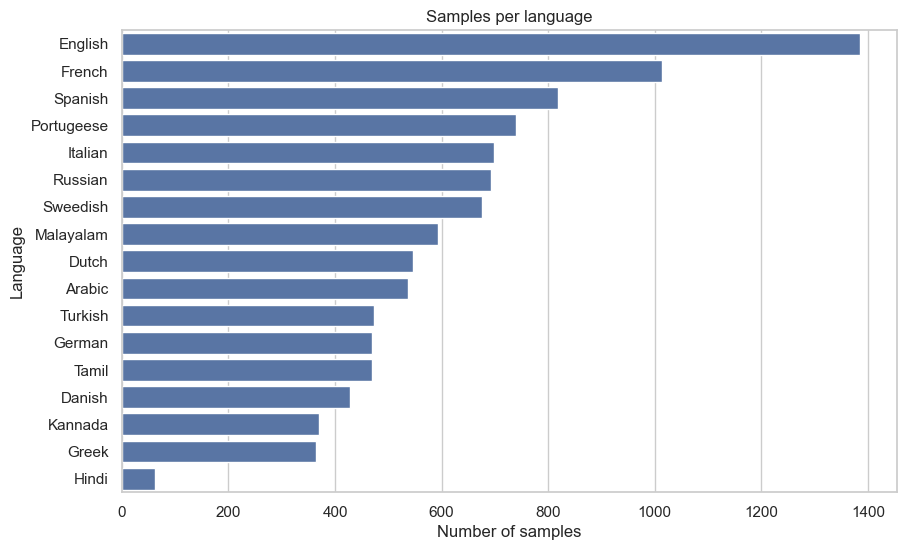

In [8]:
# Simple cleaning
df['Text'] = df['Text'].astype(str).str.strip().str.lower()

# Basic class counts
counts = df['Language'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(y=counts.index, x=counts.values)
plt.xlabel("Number of samples")
plt.title("Samples per language")
plt.show()

# Preprocessing

In [9]:
# Encoding languages to integers
le = LabelEncoder()
df['lang_id'] = le.fit_transform(df['Language'])
num_classes = len(le.classes_)
print("Languages:", list(le.classes_))
print("Number of classes:", num_classes)

Languages: ['Arabic', 'Danish', 'Dutch', 'English', 'French', 'German', 'Greek', 'Hindi', 'Italian', 'Kannada', 'Malayalam', 'Portugeese', 'Russian', 'Spanish', 'Sweedish', 'Tamil', 'Turkish']
Number of classes: 17


In [10]:
# Spliting into train/test
X = df['Text'].values
y = df['lang_id'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [11]:
# Character-level tokenizer
max_chars = 5000   # we only need up to vocabulary of chars, but set high just in case
tokenizer = Tokenizer(num_words=max_chars, char_level=True, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [12]:
# Converting text to sequences of character ids
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [13]:
# Choosing a max length in characters (short sentences, so 50 is ok)
maxlen = 50
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=maxlen, padding='post', truncating='post')

print("Sample text:", X_train[0])
print("Sample tokenized (first 10):", X_train_seq[0][:10])
print("Padded shape:", X_train_pad.shape)

Sample text: لقد واجهته أثناء رحلاته أو في مقابلة عندما سُئلت عن سبب تعيينك ، بدت محيرة تمامًا في المرة القادمة إذا كنت مرتبكًا بشأن أي أسئلة على سبيل المثال في امتحان فأنت.
Sample tokenized (first 10): [36, 170, 125, 2, 86, 30, 205, 155, 82, 155]
Padded shape: (8269, 50)


# Building character-level ANN

In [14]:
vocab_size = min(max_chars, len(tokenizer.word_index) + 1)  # actual vocab size
embedding_dim = 64

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=maxlen),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.build(input_shape=(None, maxlen))
model.summary()

C:\Users\ayush\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 50, 64)              │          31,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 17)                  │           1,105 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,625 (143.07 KB)

 Trainable params: 36,625 (143.07 KB)

 Non-trainable params: 0 (0.00 B)

# Training the model

In [15]:
history = model.fit(X_train_pad, y_train, 
                    epochs=8, 
                    batch_size=64, 
                    validation_split=0.15,
                    verbose=1)

Epoch 1/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3920 - loss: 2.2076 - val_accuracy: 0.4239 - val_loss: 1.6757
Epoch 2/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5327 - loss: 1.4334 - val_accuracy: 0.6003 - val_loss: 1.3003
Epoch 3/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6592 - loss: 1.0808 - val_accuracy: 0.6825 - val_loss: 0.9833
Epoch 4/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7254 - loss: 0.8526 - val_accuracy: 0.7035 - val_loss: 0.8278
Epoch 5/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7655 - loss: 0.7251 - val_accuracy: 0.7776 - val_loss: 0.7125
Epoch 6/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7903 - loss: 0.6415 - val_accuracy: 0.7865 - val_loss: 0.6444
Epoch 7/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8102 - loss: 0.5824 - val_accuracy: 0.7969 - val_loss: 0.5991
Epoch 8/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8241 - loss: 0.5371 - val_accuracy: 0.8187 -

# Evaluating the model

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Test accuracy: 0.8089941972920697

Classification report:
              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       107
      Danish       0.83      0.62      0.71        86
       Dutch       0.53      0.58      0.55       109
     English       0.82      0.84      0.83       277
      French       0.66      0.86      0.74       203
      German       0.81      0.61      0.70        94
       Greek       1.00      1.00      1.00        73
       Hindi       1.00      1.00      1.00        12
     Italian       0.67      0.62      0.65       140
     Kannada       1.00      1.00      1.00        74
   Malayalam       1.00      1.00      1.00       119
  Portugeese       0.59      0.80      0.68       148
     Russian       1.00      0.99      0.99       138
     Spanish       0.76      0.46      0.57       164
    Sweedish       0.86      0.85      0.86       135
       Tamil       1.00      1.00     

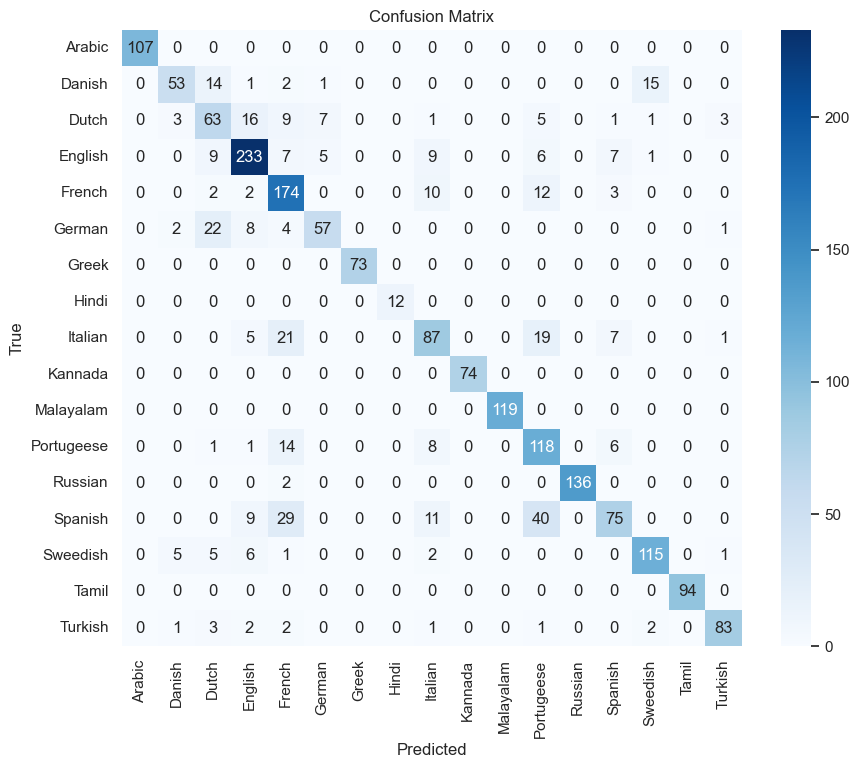

In [16]:
y_pred_proba = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_proba, axis=1)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Trying the model on new sentences

In [17]:
examples = [
    "Bonjour, comment allez-vous?",
    "This is a small English sentence.",
    "Hola, ¿cómo estás?",
    "Guten Morgen, wie geht's?",
    "Buongiorno, come stai?"
]

seq = tokenizer.texts_to_sequences([s.lower() for s in examples])
pad = pad_sequences(seq, maxlen=maxlen, padding='post')
pred = model.predict(pad)

for s, p in zip(examples, pred):
    pred_lang = le.classes_[np.argmax(p)]
    print(f"Text: {s}\nPredicted language: {pred_lang}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Text: Bonjour, comment allez-vous?
Predicted language: French

Text: This is a small English sentence.
Predicted language: German

Text: Hola, ¿cómo estás?
Predicted language: Spanish

Text: Guten Morgen, wie geht's?
Predicted language: German

Text: Buongiorno, come stai?
Predicted language: Italian

